# 🌤️ Autogen 기반 단일 에이전트 채팅 예제

이 노트북은 **`autogen_agentchat`** 프레임워크를 이용해  
Azure OpenAI 모델과 Function Calling(도구 호출)을 결합한  
**기본형 에이전트 채팅 시스템**을 구현한 예시입니다.

---

## 🧩 주요 구성 요소

| 구성 요소 | 설명 |
|------------|------|
| **AssistantAgent** | LLM 기반의 개별 에이전트. Azure OpenAI 모델을 사용하며 `tool`을 호출 가능 |
| **AzureOpenAIChatCompletionClient** | Azure OpenAI의 ChatCompletion API를 호출하는 클라이언트 |
| **RoundRobinGroupChat** | 여러 에이전트를 순차적으로 대화시키는 팀 오케스트레이터 |
| **Console** | 모델 응답을 스트리밍 형태로 콘솔에 출력하는 UI 도구 |
| **get_weather()** | 에이전트가 호출 가능한 예시 툴 (Function Calling 예시) |

---

## ⚙️ 코드 실행 흐름

1. `.env` 파일에서 Azure OpenAI 환경 변수 로드  
2. `AzureOpenAIChatCompletionClient` 생성  
3. `get_weather()` 툴 정의 (모의 함수)  
4. `AssistantAgent` 생성 및 툴 연결  
5. `RoundRobinGroupChat`으로 에이전트를 팀에 등록  
6. 사용자 입력을 받아 모델 응답을 스트리밍 출력  
7. `'exit'` 입력 시 종료  

---

In [2]:
import os

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient
from dotenv import load_dotenv

load_dotenv()

api_version = os.getenv("AZURE_OPENAI_API_VERSION")
api_key = os.getenv("AZURE_OPENAI_API_KEY")
azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
deployment_name = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")
azure_openai_chat_completion_client = AzureOpenAIChatCompletionClient(
            model=deployment_name,
            azure_endpoint=azure_endpoint,
            api_version=api_version,
            api_key=api_key,
        )

# Define a tool
async def get_weather(city: str) -> str:
    return f"The weather in {city} is 73 degrees and Sunny."


async def main() -> None:
    # Define an agent
    weather_agent = AssistantAgent(
        name="weather_agent",
        model_client=azure_openai_chat_completion_client,
        tools=[get_weather],
    )

    # Define a team with a single agent and maximum auto-gen turns of 1.
    agent_team = RoundRobinGroupChat([weather_agent], max_turns=1)

    while True:
        # Get user input from the console.
        user_input = input("Enter a message (type 'exit' to leave): ")
        if user_input.strip().lower() == "exit":
            break
        # Run the team and stream messages to the console.
        stream = agent_team.run_stream(task=user_input)
        await Console(stream)


# NOTE: if running this inside a Python script you'll need to use asyncio.run(main()).
await main()

---------- TextMessage (user) ----------
안녕
---------- TextMessage (weather_agent) ----------
안녕하세요! 무엇을 도와드릴까요?
---------- TextMessage (user) ----------
날이 추워
---------- TextMessage (weather_agent) ----------
어느 도시의 날씨가 추운가요? 도시 이름을 알려주시면 현재 날씨를 알려드릴게요.
---------- TextMessage (user) ----------
서울이야
---------- ToolCallRequestEvent (weather_agent) ----------
[FunctionCall(id='call_Yx7jHX4sonMMWckXHUpaKvdC', arguments='{"city":"서울"}', name='get_weather')]
---------- ToolCallExecutionEvent (weather_agent) ----------
[FunctionExecutionResult(content='The weather in 서울 is 73 degrees and Sunny.', name='get_weather', call_id='call_Yx7jHX4sonMMWckXHUpaKvdC', is_error=False)]
---------- ToolCallSummaryMessage (weather_agent) ----------
The weather in 서울 is 73 degrees and Sunny.


# 🧠 Autogen 기반 멀티모달 입력(텍스트+이미지) 예제

이 노트북은 **`autogen_agentchat`** 프레임워크로  
LLM이 **텍스트와 이미지**를 함께 받아 이해하고 응답하도록 구성한 **기본 예시**입니다.

---

## 🧩 주요 구성 요소

| 구성 요소 | 역할 |
|---|---|
| **TextMessage** | 순수 텍스트 메시지 객체 |
| **MultiModalMessage** | 텍스트와 이미지를 함께 담는 멀티모달 메시지 |
| **AGImage** | `PIL.Image`를 autogen에서 인식 가능한 이미지 타입으로 변환 |
| **AssistantAgent** | Azure OpenAI 모델을 사용하는 에이전트 |
| **CancellationToken** | 요청 취소/타임아웃 제어용 토큰 |
| **matplotlib** | 노트북에서 이미지 미리보기 |

---

## ⚙️ 동작 흐름

1. 웹에서 이미지를 **다운로드**하고 `PIL.Image`로 로드
2. 이미지를 **AGImage**로 래핑
3. 텍스트 프롬프트 + 이미지를 **MultiModalMessage**로 결합
4. **AssistantAgent**에 메시지를 전달해 **LLM 멀티모달 추론** 수행
5. **응답(이미지 설명)** 을 콘솔에 출력, 이미지는 노트북에 표시

---

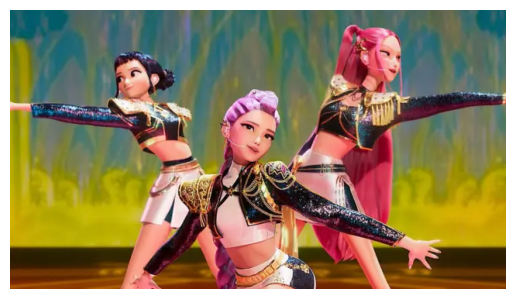

['이미지에는 독특하고 화려한 공연 의상을 입고 무대에서 춤을 추는 세 명의 사람이 있습니다. 그들은 각기 다른 포즈를 취하며 에너지와 동작을 보여주고 있습니다.']
id='860bb84c-676b-4069-b0ea-11fdfab429f0' source='assistant' models_usage=RequestUsage(prompt_tokens=305, completion_tokens=50) metadata={} created_at=datetime.datetime(2025, 10, 17, 15, 4, 57, 341044, tzinfo=datetime.timezone.utc) content='이미지에는 독특하고 화려한 공연 의상을 입고 무대에서 춤을 추는 세 명의 사람이 있습니다. 그들은 각기 다른 포즈를 취하며 에너지와 동작을 보여주고 있습니다.' type='TextMessage'


In [5]:
from autogen_agentchat.messages import TextMessage

# text_message = TextMessage(content="Hello, world!", source="User")

from io import BytesIO

import matplotlib.pyplot as plt
import requests
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import CancellationToken
from autogen_core import Image as AGImage
from PIL import Image

pil_image = Image.open(BytesIO(requests.get("https://ichef.bbci.co.uk/ace/ws/640/cpsprodpb/c82c/live/d2c695c0-8408-11f0-84c8-99de564f0440.jpg.webp").content))
img = AGImage(pil_image)
multi_modal_message = MultiModalMessage(content=["이미지 설명과 이미지에 사람이 몇 명있는지 알려줘.", img], source="User")

plt.imshow(pil_image) 
plt.axis('off') 
plt.show()

agent = AssistantAgent(
    name="assistant",
    model_client=azure_openai_chat_completion_client,
    system_message="Use tools to solve tasks.",
)

async def assistant_run() -> None:
    response = await agent.on_messages(
        [multi_modal_message],
        cancellation_token=CancellationToken(),
    )

    print([response.chat_message.content])

    print(response.chat_message)



# Use asyncio.run(assistant_run()) when running in a script.
await assistant_run()

# 🔍 Autogen 기반 단일 에이전트 Tool-Calling 예제

이 노트북은 **`autogen_agentchat`** 프레임워크를 활용해  
Azure OpenAI 모델이 **Function Calling (도구 호출)** 기능을 사용하여  
사용자 요청에 맞게 **외부 함수를 실행하고 응답하는 에이전트**를 구현한 예제입니다.

---

## 🧩 주요 구성 요소

| 구성 요소 | 설명 |
|------------|------|
| **AssistantAgent** | LLM 기반의 에이전트, 필요 시 등록된 툴을 호출 |
| **web_search()** | 예시 툴(Function), 검색 결과를 반환 |
| **TextMessage** | 사용자 입력 메시지 객체 |
| **CancellationToken** | 비동기 실행 중 요청 취소를 제어 |
| **AzureOpenAIChatCompletionClient** | Azure OpenAI API 호출 클라이언트 |

---

## ⚙️ 동작 흐름

1. `web_search()` 툴 정의  
2. `AssistantAgent`에 툴 등록  
3. 사용자의 텍스트 입력을 `TextMessage`로 전달  
4. LLM이 입력을 분석 → 툴을 호출 → 결과를 받아 응답 생성  
5. 최종 응답(`response.chat_message.content`) 출력  

---

## 🧠 확장 아이디어

- 실제 **웹 검색 API** 연동 (예: Bing, Google, Serper 등)  
- 여러 개의 툴 등록 (예: 검색 + 요약 + 번역)  
- **멀티 에이전트 구조**로 협업 (예: Research Agent ↔ Summarizer Agent)  
- **RAG 통합**: Azure AI Search 결과를 툴 호출로 연결  

---
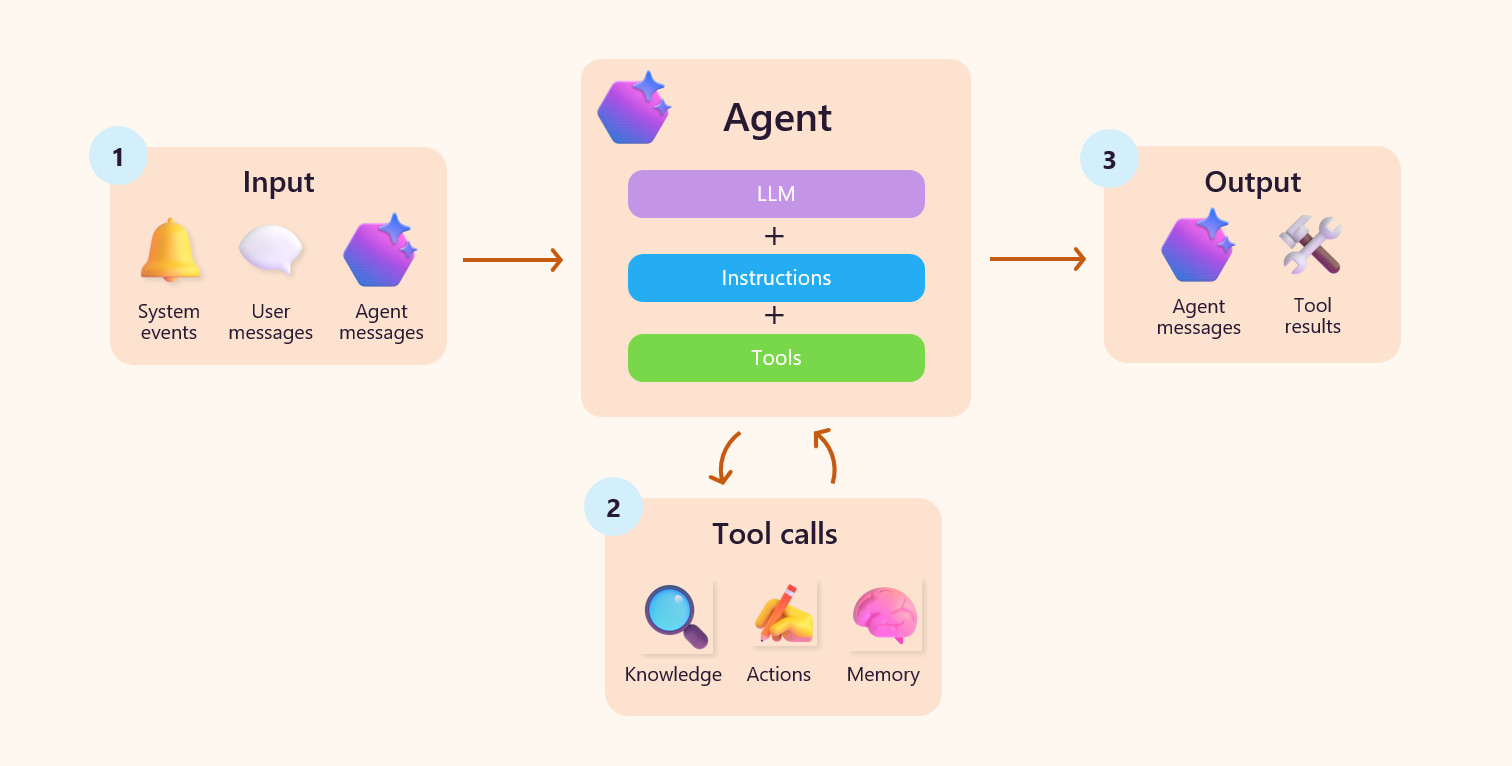


In [8]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.messages import TextMessage
from autogen_core import CancellationToken


# Define a tool that searches the web for information.
async def web_search(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."


# Create an agent that uses the OpenAI GPT-4o model.
model_client = azure_openai_chat_completion_client
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

async def assistant_run() -> None:
    response = await agent.on_messages(
        [TextMessage(content="Find information on AutoGen", source="user")],
        cancellation_token=CancellationToken(),
    )
    print(response.inner_messages)
    print(response.chat_message.content)


# Use asyncio.run(assistant_run()) when running in a script.
await assistant_run()

[ToolCallRequestEvent(id='a06a38c7-0a21-4307-ba77-1669b6a0b3c0', source='assistant', models_usage=RequestUsage(prompt_tokens=61, completion_tokens=16), metadata={}, created_at=datetime.datetime(2025, 10, 17, 11, 3, 56, 885112, tzinfo=datetime.timezone.utc), content=[FunctionCall(id='call_OEXX4kXJgYk5U7HDilDgP9NI', arguments='{"query":"AutoGen"}', name='web_search')], type='ToolCallRequestEvent'), ToolCallExecutionEvent(id='ba8b7947-621a-4ef9-a8a5-454146cb9ad8', source='assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 10, 17, 11, 3, 56, 885478, tzinfo=datetime.timezone.utc), content=[FunctionExecutionResult(content='AutoGen is a programming framework for building multi-agent applications.', name='web_search', call_id='call_OEXX4kXJgYk5U7HDilDgP9NI', is_error=False)], type='ToolCallExecutionEvent')]
AutoGen is a programming framework for building multi-agent applications.


# 👤 Autogen UserProxyAgent 예제

이 노트북은 **`autogen_agentchat`** 프레임워크에서  
**사용자 역할을 시뮬레이션하는 UserProxyAgent**의 기본 동작을 보여주는 예시입니다.

---

## 🧩 주요 구성 요소

| 구성 요소 | 설명 |
|------------|------|
| **UserProxyAgent** | 사용자의 역할을 대신 수행하는 프록시 에이전트 |
| **TextMessage** | 사용자 발화(입력 메시지)를 표현하는 객체 |
| **CancellationToken** | 요청 취소 및 비동기 제어용 객체 |

---

## ⚙️ 동작 흐름

1. `UserProxyAgent` 생성  
2. 사용자 메시지(`TextMessage`) 전달  
3. `on_messages()` 호출 → UserProxyAgent가 응답 생성  
4. `response.chat_message.content` 출력  

---

In [ ]:
from autogen_agentchat.agents import UserProxyAgent
from autogen_agentchat.messages import TextMessage
from autogen_core import CancellationToken


async def user_proxy_run() -> None:
    user_proxy_agent = UserProxyAgent("user_proxy")
    response = await user_proxy_agent.on_messages(
        [TextMessage(content="What is your name? ", source="user")], cancellation_token=CancellationToken()
    )
    print(f"Your name is {response.chat_message.content}")


# Use asyncio.run(user_proxy_run()) when running in a script.
await user_proxy_run()

# 💬 Autogen 스트리밍 출력(Streaming Response) 예제

이 노트북은 **`autogen_agentchat`** 프레임워크에서  
LLM이 생성하는 응답을 **실시간으로 콘솔에 출력하는 방법**을 보여줍니다.

---

## ⚙️ 주요 구성 요소

| 구성 요소 | 설명 |
|------------|------|
| **agent.on_messages_stream()** | 모델 응답을 토큰 단위로 비동기 스트림 형태로 반환 |
| **TextMessage** | 사용자 입력 메시지 객체 |
| **CancellationToken** | 비동기 실행 중 요청 취소 제어 |
| **Console** | 스트림으로 전달된 토큰을 실시간으로 콘솔에 표시 |

---

## 🧩 동작 흐름

1. 사용자가 `"Find information on AutoGen"` 입력  
2. `AssistantAgent`가 모델에 요청 전송  
3. LLM이 응답을 생성하며 토큰 단위로 반환  
4. `Console()`이 실시간으로 출력  

---

In [6]:
from autogen_agentchat.ui import Console


async def assistant_run_stream() -> None:
    # Option 1: read each message from the stream (as shown in the previous example).
    # async for message in agent.on_messages_stream(
    #     [TextMessage(content="Find information on AutoGen", source="user")],
    #     cancellation_token=CancellationToken(),
    # ):
    #     print(message)

    # Option 2: use Console to print all messages as they appear.
    await Console(
        agent.on_messages_stream(
            [TextMessage(content="Find information on AutoGen", source="user")],
            cancellation_token=CancellationToken(),
        )
    )


# Use asyncio.run(assistant_run_stream()) when running in a script.
await assistant_run_stream()

---------- assistant ----------
AutoGen is an open-source framework developed by Microsoft designed to facilitate the creation and management of AI systems composed of multiple agents that can autonomously collaborate to accomplish complex tasks. It enables users to define interactions between AI agents and integrate external APIs, effectively allowing the agents to communicate, coordinate, and perform various functions in a dynamic environment. AutoGen supports different AI models and provides tools for managing conversations, decision-making processes, and task execution across agents. It is particularly useful for building sophisticated multi-agent applications in areas such as automation, data processing, and interactive systems.


# 🧠 Autogen 메모리(ListMemory) + AssistantAgent 예제

이 노트북은 `autogen_core.memory`의 **ListMemory** 를 사용해  
에이전트가 **사용자 선호/사실을 기억하고 질의에 활용**하도록 구성한 예시입니다.

---

## 🧩 구성 요소

- **ListMemory**: 간단한 리스트 기반 인메모리 저장소(휘발성)
- **MemoryContent**: 메모리에 저장되는 레코드(본문 + MIME 타입)
- **AssistantAgent(memory=[...])**: 메모리를 참조해 답변 맥락 강화
- **run_stream + Console**: 스트리밍 응답(노트북은 보통 한 번에 출력됨)

---

## ⚙️ 동작 흐름

1. `ListMemory()` 초기화
2. 사용자 정보(선호/사실)를 `MemoryContent(TEXT)`로 추가
3. 메모리를 장착한 `AssistantAgent` 생성
4. 질문 실행 → 에이전트가 메모리 내용을 활용해 응답 생성
5. `Console(stream)`으로 출력

---

## 🚀 확장 아이디어

- **영속/장기 메모리**: 파일/DB/벡터스토어 기반 Memory 구현
- **세분화**: 프로필/세션/지식 메모리 분리 관리

In [7]:
from autogen_core.memory import ListMemory, MemoryContent, MemoryMimeType

# Initialize user memory
user_memory = ListMemory()

# Add user preferences to memory
await user_memory.add(MemoryContent(content="난 고양이를 좋아해", mime_type=MemoryMimeType.TEXT))

await user_memory.add(MemoryContent(content="내 생일은 7월 31 일이야", mime_type=MemoryMimeType.TEXT))

assistant_agent = AssistantAgent(
    name="assistant_agent",
    model_client=azure_openai_chat_completion_client,
    memory=[user_memory],
)

stream = assistant_agent.run_stream(task="내 생일은 언제야? 내가 좋아하는 애완동물은?")
await Console(stream)

---------- TextMessage (user) ----------
내 생일은 언제야? 내가 좋아하는 애완동물은?
---------- MemoryQueryEvent (assistant_agent) ----------
[MemoryContent(content='난 고양이를 좋아해', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None), MemoryContent(content='내 생일은 7월 31 일이야', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None)]
---------- TextMessage (assistant_agent) ----------
당신의 생일은 7월 31일이고, 좋아하는 애완동물은 고양이입니다.


TaskResult(messages=[TextMessage(id='06423ec5-7c6c-40e0-91e3-35535e1f14c7', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 10, 17, 15, 11, 28, 995623, tzinfo=datetime.timezone.utc), content='내 생일은 언제야? 내가 좋아하는 애완동물은?', type='TextMessage'), MemoryQueryEvent(id='dff43472-95fb-4e6e-be92-117b1c459084', source='assistant_agent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 10, 17, 15, 11, 28, 998537, tzinfo=datetime.timezone.utc), content=[MemoryContent(content='난 고양이를 좋아해', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None), MemoryContent(content='내 생일은 7월 31 일이야', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None)], type='MemoryQueryEvent'), TextMessage(id='f4be3737-c76e-48bb-b3a7-53e27c36498d', source='assistant_agent', models_usage=RequestUsage(prompt_tokens=88, completion_tokens=27), metadata={}, created_at=datetime.datetime(2025, 10, 17, 15, 11, 31, 63620, tzinfo=datetime.timezone.utc), content='당신의 생일은 7월 